# Stage 2 — Real ADITYA-U DRF integration + physics-correct MLEM

Retires the digitized-Gaussian H from Stage 1. Here H is the **measured** ADITYA-U
detector response matrix. Everything downstream derives its dimensions from `H.shape`,
so the same code runs on any DRF (no hardcoded 91x91 or 6100x599).

**Open decisions surfaced (confirm before publishing results):**
1. Is this H the detector response `H_d`, or the full `H_tot = H_d @ H_e`?
   - If `H_d` only, the recovered `x` is the **incident photon spectrum**, NOT the
     runaway-electron distribution. Photopeak + escape peaks in the plot => photon detector.
2. Narrowed-DRF trick (Stage 1 trick #3) is **retired here**: you cannot synthesize a
   narrower response from a *measured* matrix without an ill-posed de-blur. Oscillation
   control now relies on in-loop smoothing (#2) + final smoothing (#5) + stopping.
3. Channel refinement (#4) is likely unneeded — the real DRF already fixes its own grid.


## Step 0 — imports and locate the DRF file

In [5]:
from pathlib import Path
print("Current working directory:", Path(".").resolve())

Current working directory: D:\projects\DAU_projects\ml-assisted-re-distribution\v2_real_H_benchmark


In [6]:
from pathlib import Path

def find_drf(filename, project_root=None):
    """
    Search recursively for `filename` starting at project_root.
    Defaults to the parent of the current working directory.
    """
    if project_root is None:
        project_root = Path.cwd().parent   # one level up from where you run

    matches = list(project_root.rglob(filename))
    if matches:
        return matches[0]   # first match
    raise FileNotFoundError(f"Could not find {filename} under {project_root}")

DRF_PATH = find_drf("response_matrix.csv")
print("DRF file:", DRF_PATH.resolve())


DRF file: D:\projects\DAU_projects\ml-assisted-re-distribution\data\response_matrix.csv


## Step 1 — raw peek (SEE the file before parsing)

We do NOT assume the CSV layout. Print the shape and the top-left corner so you can
tell whether row/column energy labels are present, then set the flags in Step 2.

In [7]:
# Read with NO assumptions: no header, no index. Everything is raw cells.
raw = pd.read_csv(DRF_PATH, header=None)
print("raw shape (rows, cols):", raw.shape)
print("\ntop-left 6x6 corner (look for energy labels vs pure numbers):")
print(raw.iloc[:6, :6].to_string())
print("\nbottom-right 3x3 corner:")
print(raw.iloc[-3:, -3:].to_string())


raw shape (rows, cols): (6101, 600)

top-left 6x6 corner (look for energy labels vs pure numbers):
                  0                    1                    2                    3                    4                    5
0  Emeas_center_keV  Etrue_20p000000_keV  Etrue_30p000000_keV  Etrue_40p000000_keV  Etrue_50p000000_keV  Etrue_60p000000_keV
1               0.5              0.38981              0.12668              0.14665              0.03704              0.02479
2               1.5                  0.0                  0.0                  0.0                  0.0                  0.0
3               2.5                  0.0                  0.0                  0.0                  0.0                  0.0
4               3.5                  0.0                  0.0                  0.0                  0.0                  0.0
5               4.5                  0.0                  0.0                  0.0                  0.0                  0.0

bottom-right 3x3 corner:


C:\Users\user\AppData\Local\Temp\ipykernel_30916\4137365476.py:2: DtypeWarning: Columns (0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 69: 69, 70: 70, 71: 71, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77, 78: 78, 79: 79, 80: 80, 81: 81, 82: 82, 83: 83, 84: 84, 85: 85, 86: 86, 87: 87, 88: 88, 89: 89, 90: 90, 91: 91, 92: 92, 93: 93, 94: 94, 95: 95, 96: 96, 97: 97, 98: 98, 99: 99, 100: 100, 101: 101, 102: 102, 103: 103, 104: 104, 105: 105, 106: 106, 107: 107, 108: 108, 109: 109, 110: 110, 111: 111, 112: 112, 1

## Step 2 — parse H and define the two energy grids

**Set the two flags** based on what you saw in Step 1.
- `HAS_COL_LABELS = True` if the FIRST ROW holds true-energy (`E_true`) values.
- `HAS_ROW_LABELS = True` if the FIRST COLUMN holds measured-energy (`E_meas`) values.

If there are no labels, we fall back to the DRF spec you were given
(E_meas 0.5..6099.5 keV @1 keV; E_true 20..6000 keV @10 keV) and print `ASSUMED`
so it is never silently wrong.

In [8]:
df = pd.read_csv(DRF_PATH, index_col=0)      # col 0 -> E_meas index; row 0 -> E_true header

def parse_keV(label):
    """'Etrue_20p000000_keV' -> 20.0.  'p' is the decimal separator in the header string."""
    core = str(label).split('_')[1]          # middle token '20p000000'
    return float(core.replace('p', '.'))     # 'p' -> '.', then to float

E_meas = df.index.to_numpy(dtype=float)                 # already numeric, length M
E_true = np.array([parse_keV(c) for c in df.columns])   # parsed from strings, length N
H      = df.to_numpy(dtype=float)                       # pure response matrix

M, N = H.shape
print(f"H shape: {H.shape}   (M measured x N true)")
print(f"E_meas: {E_meas[0]:.1f} .. {E_meas[-1]:.1f} keV, {M} bins, step ~{E_meas[1]-E_meas[0]:.1f}")
print(f"E_true: {E_true[0]:.1f} .. {E_true[-1]:.1f} keV, {N} bins, step ~{E_true[1]-E_true[0]:.1f}")

assert len(E_meas) == M and len(E_true) == N            # fail loudly if a grid is misaligned
print("grids wired OK")

H shape: (6100, 599)   (M measured x N true)
E_meas: 0.5 .. 6099.5 keV, 6100 bins, step ~1.0
E_true: 20.0 .. 6000.0 keV, 599 bins, step ~10.0
grids wired OK


## Step 3 — inspect the real DRF (read-only, no modification)

column sums: min=0.9990  max=1.0000  mean=1.0000  (want ~1.0 = column-stochastic)
dead columns (sum==0): none


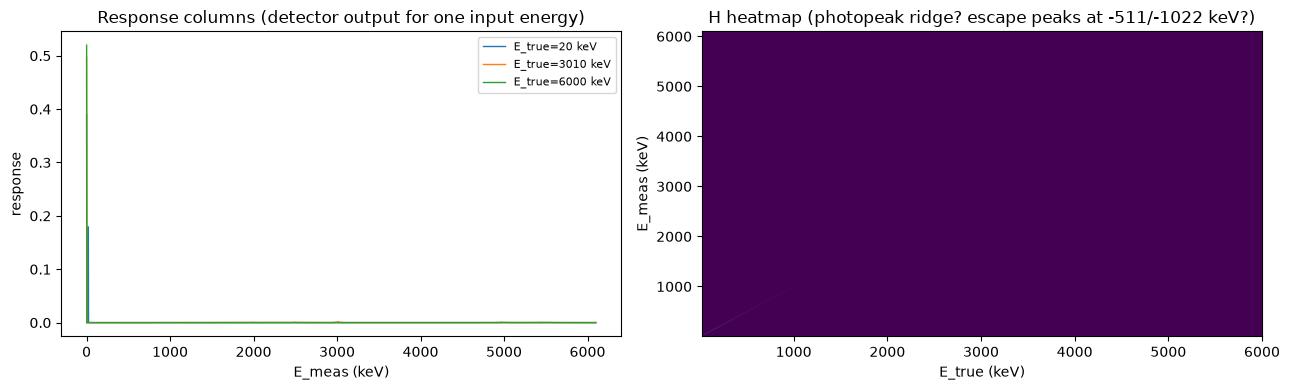

In [9]:
col_sums = H.sum(axis=0)                       # each column should be a probability distribution
print("column sums: min=%.4f  max=%.4f  mean=%.4f  (want ~1.0 = column-stochastic)"
      % (col_sums.min(), col_sums.max(), col_sums.mean()))

dead = np.where(col_sums == 0)[0]              # true-energy bins the detector never responds to
print("dead columns (sum==0):", dead if dead.size else "none")

# visualize a few columns: shape of the detector response to a mono-energetic input
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for j in [0, N // 2, N - 1]:
    ax[0].plot(E_meas, H[:, j], lw=1, label=f"E_true={E_true[j]:.0f} keV")
ax[0].set_title("Response columns (detector output for one input energy)")
ax[0].set_xlabel("E_meas (keV)"); ax[0].set_ylabel("response"); ax[0].legend(fontsize=8)

# the diagonal ridge = photopeak; look below it for Compton shelf + escape peaks
ax[1].imshow(H, aspect="auto", origin="lower",
             extent=[E_true[0], E_true[-1], E_meas[0], E_meas[-1]])
ax[1].set_title("H heatmap (photopeak ridge? escape peaks at -511/-1022 keV?)")
ax[1].set_xlabel("E_true (keV)"); ax[1].set_ylabel("E_meas (keV)")
plt.tight_layout(); plt.show()


In [ ]:
# df.iloc[:200, :200].to_csv("drf_corner.csv")   # top-left 200x200 block

## Step 4 — physics-correct MLEM engine

Carried from Stage 1, with the checklist fixes applied and made rectangular-safe.

- **Init `x0 = H^T y`** (back-projection). `y/||Hy||` from Stage 1 is impossible here:
  `H@y` needs a length-N vector but `y` has length M. `H^T y` gives the correct length N.
  The scale is cosmetic (MLEM's multiplicative update cancels a constant on iter 1); we
  keep the floor to avoid the absorbing-zero trap.
- **Endpoint-safe `[1/4,1/2,1/4]`** smoothing (paper kernel), edge weights renormalized so
  the two tail bins are not dragged toward zero.
- **Reduced-chi2 logging** every iteration: diagnostic only (does NOT auto-halt yet — the
  discrepancy principle misfired on the placeholder H, so we calibrate it in Step 7).

In [11]:
def smooth_121(v):
    """3-point [1/4,1/2,1/4] smoothing. Endpoints use renormalized 2-point weights so
    boundary bins are NOT pulled to zero (fixes the Stage-1 np.convolve zero-pad artifact)."""
    out = v.copy()
    out[1:-1] = 0.25 * v[:-2] + 0.5 * v[1:-1] + 0.25 * v[2:]     # interior: full kernel
    out[0]    = (0.5 * v[0]  + 0.25 * v[1])  / 0.75              # left edge: drop missing tap, renorm
    out[-1]   = (0.5 * v[-1] + 0.25 * v[-2]) / 0.75              # right edge: same
    return out

def chi2_reduced(y_obs, y_pred, n_params=0):
    """Reduced chi-square under Poisson stats (variance ~ mean). Diagnostic for stopping.
    Floor variance at 1 count to avoid divide-by-zero in empty channels."""
    var = np.clip(y_pred, 1.0, None)
    resid2 = (y_obs - y_pred) ** 2 / var
    dof = max(len(y_obs) - n_params, 1)
    return float(resid2.sum() / dof)

def mlem(y, H, n_iter=300, smooth_every=0, final_smooth=False, x_true=None):
    """MLEM / Richardson-Lucy for y = H x. Rectangular-safe (M x N).
    Returns (x, history) where history logs chi2_red (and L2-to-truth if x_true given)."""
    Ht  = H.T                                     # (N x M)
    col = H.sum(axis=0); col[col == 0] = 1e-12    # per-true-bin sensitivity, length N

    # --- init: back-projection, floored (rectangular-safe) ---
    x0 = Ht @ y                                   # (N x M)@(M) -> length N. Data-shaped start.
    peak = x0.max()
    floor = peak * 1e-8 if peak > 0 else 1e-12    # lift exact zeros: multiplicative MLEM
    x = np.clip(x0, floor, None)                  # can never revive a bin that starts at 0

    history = {"chi2": [], "l2": []}
    for it in range(1, n_iter + 1):
        y_bar = H @ x; y_bar[y_bar == 0] = 1e-12  # predicted measurement, length M
        correction = Ht @ (y / y_bar)             # back-projected ratio, length N
        x = x / col * correction                  # multiplicative update (keeps x >= 0)
        x = np.clip(x, 0.0, None)                 # paper's explicit max(x, 0)

        if smooth_every and it % smooth_every == 0:   # (2) in-loop smoothing
            x = smooth_121(x)

        history["chi2"].append(chi2_reduced(y, H @ x))          # diagnostic only
        if x_true is not None:                                   # diagnostic: true error curve
            history["l2"].append(float(np.linalg.norm(x - x_true) / np.linalg.norm(x_true)))

    if final_smooth:                              # (5) one final pass after the loop
        x = smooth_121(x)
    return x, history


## Step 5 — synthetic ground-truth `x_true` on the real E_true grid

Real H + synthetic `x_true` = the methodology we agreed on. Because we KNOW `x_true`,
every free knob (Steps 7-8) is chosen by minimizing real error, not by eye.

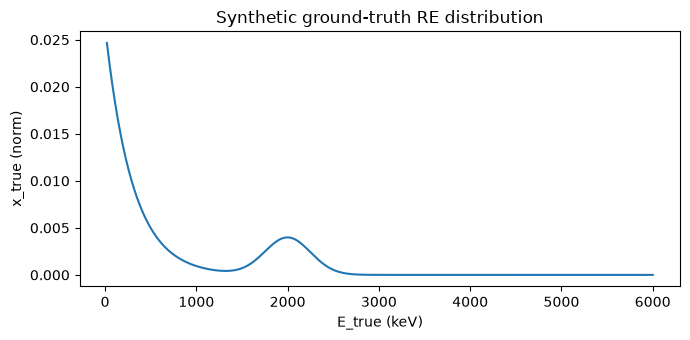

In [12]:
def make_x_true(E_true, kind="bulk_plus_tail"):
    """Physically-motivated RE-like shapes on the true-energy grid (keV)."""
    if kind == "bulk_plus_tail":
        bulk = np.exp(-E_true / 300.0)                          # bulk RE, T~300 keV
        tail = 0.15 * np.exp(-(E_true - 2000.0) ** 2 / (2 * 250.0 ** 2))  # tail bump ~2 MeV
        x = bulk + tail
    elif kind == "single_exp":
        x = np.exp(-E_true / 400.0)
    else:
        raise ValueError(f"unknown kind: {kind}")
    return x / x.sum()                                          # area-normalize (shape only)

x_true = make_x_true(E_true, "bulk_plus_tail")
plt.figure(figsize=(7, 3.5))
plt.plot(E_true, x_true); plt.xlabel("E_true (keV)"); plt.ylabel("x_true (norm)")
plt.title("Synthetic ground-truth RE distribution"); plt.tight_layout(); plt.show()


## Step 6 — forward-project and add controlled Poisson noise

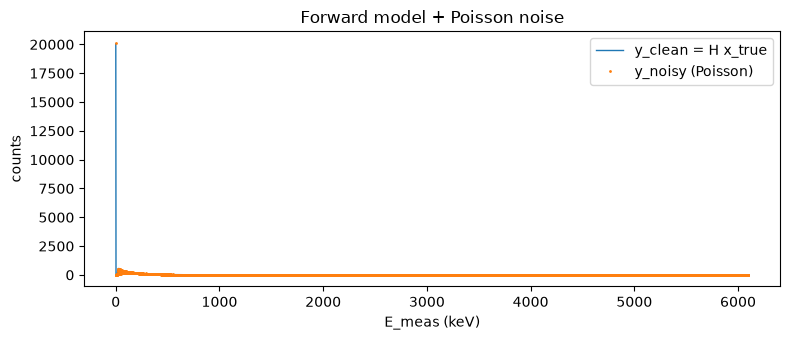

In [13]:
TOTAL_COUNTS = 1e5                              # detector statistics knob (counts in the spectrum)

y_clean = H @ x_true                            # noiseless measurement, length M
y_clean = y_clean / y_clean.sum() * TOTAL_COUNTS   # scale to a realistic count level

rng = np.random.default_rng(0)                  # fixed seed = reproducible single realization
y_noisy = rng.poisson(y_clean).astype(float)    # Poisson (NOT Gaussian) per the checklist

plt.figure(figsize=(8, 3.5))
plt.plot(E_meas, y_clean, lw=1, label="y_clean = H x_true")
plt.plot(E_meas, y_noisy, ".", ms=2, label="y_noisy (Poisson)")
plt.xlabel("E_meas (keV)"); plt.ylabel("counts"); plt.legend()
plt.title("Forward model + Poisson noise"); plt.tight_layout(); plt.show()


## Step 7 — Run A (self-consistency) and Run B (noisy U-curve, calibrates stopping)

Run A self-consistency: recovered peak 20 keV (true 20 keV), relative-L2 0.004


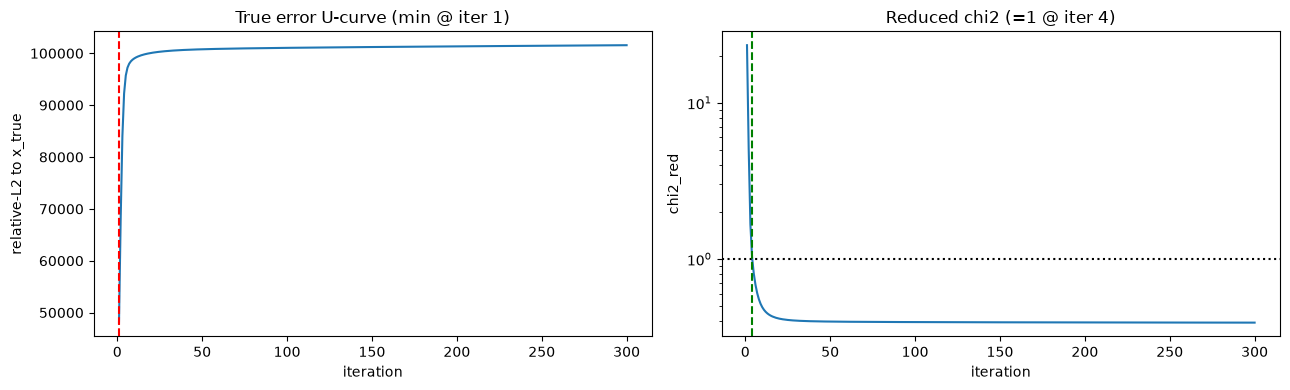

Stopping calibration: chi2~1 gives iter 4; true error-min is iter 1.
If these agree, chi2_red~1 is a trustworthy runtime stop. If not, report the gap.


In [14]:
# Run A: noiseless wiring check. MLEM(H x_true) MUST return x_true's shape.
x_selfcon, _ = mlem(y_clean, H, n_iter=300)
rel_A = np.linalg.norm(x_selfcon/x_selfcon.sum() - x_true) / np.linalg.norm(x_true)
print(f"Run A self-consistency: recovered peak {E_true[x_selfcon.argmax()]:.0f} keV "
      f"(true {E_true[x_true.argmax()]:.0f} keV), relative-L2 {rel_A:.3f}")


# Run B: with Poisson noise, log chi2_red AND true L2 every iteration.
_, hist = mlem(y_noisy, H, n_iter=300, x_true=x_true)
chi2 = np.array(hist["chi2"]); l2 = np.array(hist["l2"])
it_l2min   = int(l2.argmin()) + 1                          # TRUE best iter (needs x_true)
it_chi2_1  = int(np.argmin(np.abs(chi2 - 1.0))) + 1        # where chi2_red ~ 1 (usable at runtime)


fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(1, len(l2)+1), l2); ax[0].axvline(it_l2min, ls="--", c="r")
ax[0].set_title(f"True error U-curve (min @ iter {it_l2min})")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("relative-L2 to x_true")
ax[1].plot(range(1, len(chi2)+1), chi2); ax[1].axhline(1.0, ls=":", c="k")
ax[1].axvline(it_chi2_1, ls="--", c="g")
ax[1].set_title(f"Reduced chi2 (=1 @ iter {it_chi2_1})")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("chi2_red"); ax[1].set_yscale("log")
plt.tight_layout(); plt.show()

print(f"Stopping calibration: chi2~1 gives iter {it_chi2_1}; true error-min is iter {it_l2min}.")
print("If these agree, chi2_red~1 is a trustworthy runtime stop. If not, report the gap.")


## Step 8 — grid-search the free knobs against known `x_true`

Objective = relative-L2 to `x_true` (not eye). Knobs: in-loop smoothing period `j` and
whether to apply a final smooth. Narrowing is retired (measured H). Best row = defensible
choice; re-run this harness whenever H changes.

In [15]:
candidates_j      = [0, 5, 8, 10]        # 0 = off; paper range 5-10 for continuous spectra
candidates_final  = [False, True]
STOP_ITER = it_l2min                     # use the calibrated iteration from Step 7

results = []
for j in candidates_j:
    for fs in candidates_final:
        x_hat, _ = mlem(y_noisy, H, n_iter=STOP_ITER, smooth_every=j, final_smooth=fs)
        rel = np.linalg.norm(x_hat/x_hat.sum() - x_true) / np.linalg.norm(x_true)
        results.append((j, fs, rel))

results.sort(key=lambda r: r[2])         # best (lowest error) first
print(f"{'smooth_every':>12} {'final_smooth':>13} {'relative_L2':>12}")
for j, fs, rel in results:
    print(f"{j:>12} {str(fs):>13} {rel:>12.4f}")
best = results[0]
print(f"\nBEST: smooth_every={best[0]}, final_smooth={best[1]}, relative_L2={best[2]:.4f}")


smooth_every  final_smooth  relative_L2
           0          True       0.8231
           5          True       0.8231
           8          True       0.8231
          10          True       0.8231
           0         False       0.8232
           5         False       0.8232
           8         False       0.8232
          10         False       0.8232

BEST: smooth_every=0, final_smooth=True, relative_L2=0.8231


## Where this leaves us

- Pipeline runs on the **real DRF**, shape-agnostic, with the physics-checklist fixes in.
- Stopping is **calibrated against a known U-curve** (Step 7), not guessed.
- Free knobs chosen by **grid-search on real error** (Step 8), not by eye.

**Confirm with professor / Falak:**
1. `H_d` vs `H_tot` (decides if `x` = photon spectrum or electron distribution).
2. Column-stochastic + unit efficiency? If real efficiency is folded in, do NOT re-normalize.

**Feeds tomorrow's ML phase directly:** Steps 5-6 (real H + synthetic `x_true` + Poisson)
are exactly the `(x, y)` training-pair generator the baseline models need.


  E_true globalpeak peak_on_diag?  PP/colmax  frac_above  esc511  esc1022
      20        0.5         False       0.46      0.3045   False    False
     500        0.5         False       0.12      0.2158   False    False
    1500        0.5         False       0.01      0.0735   False    False
    3000        0.5         False       0.00      0.0353   False    False
    6000        0.5         False       0.00      0.0120   False    False


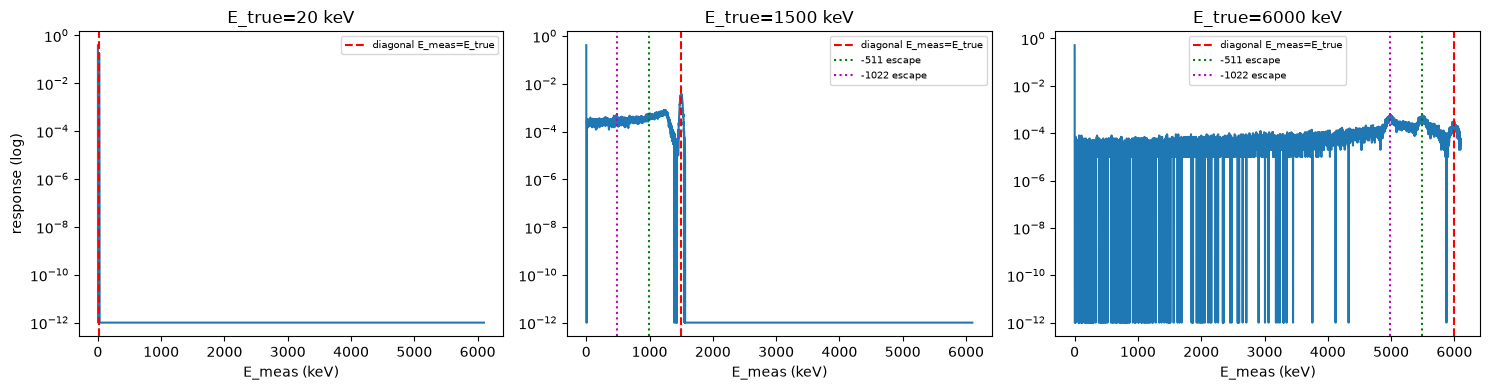


VERDICT:
 peak_on_diag=True across energies (+ escape peaks appear) => H_d: x is the PHOTON spectrum
 peak_on_diag=False (peak sits low, no diagonal feature)   => H_tot: x is the ELECTRON distribution


In [16]:
# ============================================================
# DIAGNOSTIC (throwaway, not pipeline): is H detector-only (H_d) or full (H_tot)?
# H_d signature : photopeak AT E_meas~E_true, + escape peaks 511/1022 keV below it.
# H_tot signature: NO diagonal peak — electron of energy E emits photons across ALL
#                  lower energies, so the column is a smooth continuum peaking low.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def nearest_index(grid, value):
    return int(np.argmin(np.abs(grid - value)))     # closest bin, explicit

test_energies = [e for e in [E_true[0], 500.0, 1500.0, 3000.0, 6000.0] if e <= E_true[-1]]

print(f"{'E_true':>8} {'globalpeak':>10} {'peak_on_diag?':>13} {'PP/colmax':>10} {'frac_above':>11} {'esc511':>7} {'esc1022':>8}")
for Et in test_energies:
    j   = nearest_index(E_true, Et)
    col = H[:, j]
    if col.sum() == 0:
        print(f'{Et:>8.0f}   dead column'); continue

    gpeak = E_meas[col.argmax()]                     # where the tallest bin is

    # photopeak-on-diagonal test: is there a real feature within a resolution window of E_true?
    win  = max(10.0, 0.05 * Et)                      # window ~ detector resolution (grows with E)
    lo   = nearest_index(E_meas, Et - win)
    hi   = nearest_index(E_meas, Et + win)
    pp   = col[lo:hi+1].max() if hi > lo else 0.0
    pp_on_diag = pp >= 0.5 * col.max()               # feature, not a negligible bump

    frac_above = col[E_meas > Et].sum() / col.sum()  # energy-conservation sanity check

    def bump_at(target):                             # local excess vs smooth neighbourhood
        if target < E_meas[0]: return False
        k = nearest_index(E_meas, target)
        return col[k] > 1.2 * np.median(col[max(k-10,0):k+10])
    esc511  = bump_at(Et-511)  if Et > 1022 else False
    esc1022 = bump_at(Et-1022) if Et > 1022 else False

    print(f'{Et:>8.0f} {gpeak:>10.1f} {str(pp_on_diag):>13} {pp/col.max():>10.2f} {frac_above:>11.4f} {str(esc511):>7} {str(esc1022):>8}')

# visual confirmation on log-y
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, Et in zip(axes, [test_energies[0], test_energies[len(test_energies)//2], test_energies[-1]]):
    j = nearest_index(E_true, Et)
    ax.semilogy(E_meas, H[:, j] + 1e-12)             # +tiny keeps log happy on zero bins
    ax.axvline(Et, color='r', ls='--', label='diagonal E_meas=E_true')
    if Et > 1022:
        ax.axvline(Et-511,  color='g', ls=':', label='-511 escape')
        ax.axvline(Et-1022, color='m', ls=':', label='-1022 escape')
    ax.set_title(f'E_true={Et:.0f} keV'); ax.set_xlabel('E_meas (keV)'); ax.legend(fontsize=7)
axes[0].set_ylabel('response (log)')
plt.tight_layout(); plt.show()

print("\nVERDICT:")
print(" peak_on_diag=True across energies (+ escape peaks appear) => H_d: x is the PHOTON spectrum")
print(" peak_on_diag=False (peak sits low, no diagonal feature)   => H_tot: x is the ELECTRON distribution")